# Mean Embedding Forecast LSTM Cross-Validation Evaluation (500 Basins)

This notebook evaluates and analyzes all 10 trained models from the **Mean Embedding Forecast LSTM Cross-Validation** benchmark job ([xid/278924757](https://xmanager.corp.google.com/experiments/278924757), `benchmark_500basins_me_cv`).

### Experiment Overview:
- **Model**: `mean_embedding_forecast_lstm` with multi-lead probabilistic CMAL mixture density head (`lead_time=7`, `seq_length=365`, `hidden_size=64`).
- **Data**: Multi-source weather forecasts (HRES, GraphCast, IMERG, CPC) from Caravans MultiMet dataset across 500 global catchments.
- **Cross-Validation Setup**: 5-Fold Spatial Catchment Partitioning $\times$ 2 Temporal Holdout Test Years (**2017** and **2020**) = **10 Total Cross-Validation Folds**.
- **Outputs**: Stored on CNS at `/cns/jn-d/home/floods/hydro_model/work/kruparell/mean_embedding_cv_results/benchmark_500basins_me_cv/`.


In [1]:
%matplotlib inline
import os
import sys
import re
import time
import subprocess
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import xarray as xr
from IPython.display import display, HTML

# Resolve repository root
cwd = Path(os.getcwd()).resolve()
repo_root = next(
    (p for p in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent, Path("/usr/local/google/home/kruparell/flood-forecasting")] if (p / "googlehydrology").is_dir() or (p / "tutorial").is_dir()),
    cwd
)
tut_dir = repo_root / "tutorial" if (repo_root / "tutorial").is_dir() else repo_root

for p in [str(repo_root), str(tut_dir), str(tut_dir / "scripts"), str(tut_dir / "notebooks")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from googlehydrology.utils.config import Config
from googlehydrology.evaluation.tester import RegressionTester
from googlehydrology.evaluation.metrics import calculate_metrics, AllNaNError

# Helpers for CNS and file operations
def cns_ls(path):
    res = subprocess.run(["fileutil", "ls", str(path)], capture_output=True, text=True)
    return [l.strip() for l in res.stdout.splitlines() if l.strip()]

def cns_read_lines(path):
    res = subprocess.run(["fileutil", "cat", str(path)], capture_output=True, text=True)
    return [l.strip() for l in res.stdout.splitlines() if l.strip()]

def cns_cp(src, dst):
    subprocess.run(["fileutil", "cp", str(src), str(dst)], check=True)

def compute_hydro_metrics(obs_np, sim_np):
    valid = ~np.isnan(obs_np) & ~np.isnan(sim_np)
    if np.sum(valid) < 5:
        return {"NSE": np.nan, "KGE": np.nan, "Pearson-r": np.nan, "RMSE": np.nan}
    obs_da = xr.DataArray(obs_np, dims=["date"])
    sim_da = xr.DataArray(sim_np, dims=["date"])
    try:
        return calculate_metrics(obs_da, sim_da, metrics=["NSE", "KGE", "Pearson-r", "RMSE"])
    except Exception:
        return {"NSE": np.nan, "KGE": np.nan, "Pearson-r": np.nan, "RMSE": np.nan}

plt.rcParams["font.size"] = 11
plt.rcParams["figure.figsize"] = (12, 6)
print("Environment and GoogleHydrology modules initialized successfully.")


Environment and GoogleHydrology modules initialized successfully.


## 1. Multi-Fold Cross-Validation Evaluation Loop

We locate all 10 cross-validation fold runs in `mean_embedding_cv_results/benchmark_500basins_me_cv/`. For each fold:
1. Load the trained weights (`model_epoch015.pt`), scaler (`scaler.nc`), and configuration.
2. Evaluate test period streamflow predictions on holdout catchments across **all 8 lead time steps (Day 0 to Day 7)**.
3. Compute hydrological validation metrics (NSE, KGE, Pearson-r, RMSE) per basin and lead time.

> **Tip:** Set `num_debug_basins = None` to evaluate all holdout catchments (~100 basins per fold), or set to an integer (e.g. `2`) for rapid interactive testing.


In [2]:
t0 = time.time()

# Settings
num_debug_basins = 2   # Set to None for full evaluation (~100 basins/fold), or integer for fast debug
cns_base = "/cns/jn-d/home/floods/hydro_model/work/kruparell/mean_embedding_cv_results/benchmark_500basins_me_cv"
local_base = repo_root / "model-runs" / "benchmark_500basins_me_cv"
local_base.mkdir(parents=True, exist_ok=True)

# Discover fold directories
all_cns_entries = cns_ls(cns_base)
fold_names = sorted([Path(e).name for e in all_cns_entries if "fold_test_yr" in Path(e).name])
print(f"Found {len(fold_names)} Cross-Validation Fold models: {fold_names}")

cv_records = []
detailed_cv_results = {}

for fold_name in fold_names:
    print(f"\n========================================================")
    print(f" Evaluating Fold: {fold_name}")
    print(f"========================================================")
    
    match = re.search(r"fold_test_yr(\d+)_b(\d+)_v(\d+)", fold_name)
    test_yr = int(match.group(1)) if match else None
    test_b_idx = int(match.group(2)) if match else None
    val_b_idx = int(match.group(3)) if match else None
    
    cns_fold_dir = f"{cns_base}/{fold_name}/me_hs64_ep15"
    sub_entries = cns_ls(cns_fold_dir)
    run_dirs = [e for e in sub_entries if "me_cv_" in e]
    if not run_dirs:
        print(f"Warning: No training run directory found in {cns_fold_dir}")
        continue
    cns_run_dir = run_dirs[-1]
    
    local_run_dir = local_base / fold_name
    local_run_dir.mkdir(parents=True, exist_ok=True)
    
    for fname in ["config.yml", "scaler.nc", "model_epoch015.pt"]:
        dst = local_run_dir / fname
        if not dst.exists() or dst.stat().st_size == 0:
            cns_cp(f"{cns_run_dir}/{fname}", str(dst))
            
    local_test_basins_file = local_run_dir / "test_basins.txt"
    if not local_test_basins_file.exists() or local_test_basins_file.stat().st_size == 0:
        test_basins_cns = f"{cns_fold_dir}/{fold_name}/test_basins.txt"
        cns_cp(test_basins_cns, str(local_test_basins_file))
        
    with open(local_test_basins_file, "r") as f:
        test_basins = [l.strip() for l in f if l.strip()]
        
    if num_debug_basins is not None:
        target_basins = test_basins[:num_debug_basins]
    else:
        target_basins = test_basins
    print(f"Holdout Test Basins to evaluate: {len(target_basins)} (out of {len(test_basins)})")
    
    temp_basin_file = local_run_dir / f"test_{len(target_basins)}basins.txt"
    with open(temp_basin_file, "w") as f:
        f.write("\n".join(target_basins) + "\n")
        
    with open(local_run_dir / "config.yml", "r") as f:
        cfg_dict = yaml.safe_load(f)
        
    cfg_dict["run_dir"] = str(local_run_dir)
    cfg_dict["base_run_dir"] = str(local_run_dir)
    cfg_dict["test_basin_file"] = str(temp_basin_file)
    cfg_dict["train_basin_file"] = str(temp_basin_file)
    cfg_dict["validation_basin_file"] = str(temp_basin_file)
    cfg_dict["statics_data_dir"] = "/usr/local/google/home/kruparell/Caravans_V2"
    cfg_dict["dynamics_data_dir"] = "/usr/local/google/home/kruparell/Caravans_MultiMet"
    cfg_dict["targets_data_dir"] = "/usr/local/google/home/kruparell/Caravans_V2"
    cfg_dict["device"] = "cuda:0" if torch.cuda.is_available() else "cpu"
    cfg_dict["verbose"] = 0
    
    with open(local_run_dir / "config.yml", "w") as f:
        yaml.dump(cfg_dict, f)
        
    cfg = Config(local_run_dir / "config.yml")
    
    zarr_files = list((local_run_dir / "test" / "model_epoch015").glob("test_results.zarr"))
    if not zarr_files:
        print(f"Running inference with RegressionTester...")
        tester = RegressionTester(cfg=cfg, run_dir=local_run_dir, period="test", init_model=True)
        tester.model.eval()
        tester.evaluate(epoch=15, save_results=True)
        zarr_files = list((local_run_dir / "test" / "model_epoch015").glob("test_results.zarr"))
        
    if not zarr_files:
        print(f"Error: test_results.zarr not found for fold {fold_name}")
        continue
        
    ds_zarr = xr.open_zarr(zarr_files[0], consolidated=False).compute()
    lead_time_steps = ds_zarr["time_step"].values
    dates = pd.to_datetime(ds_zarr["date"].values)
    
    fold_predictions = {}
    
    for b in target_basins:
        fold_predictions[b] = {"dates": dates, "lead_times": {}}
        for lt_idx, lt_val in enumerate(lead_time_steps):
            obs = ds_zarr["streamflow_obs"].sel(basin=b).isel(freq=0, time_step=lt_idx).values.flatten()
            sim = np.maximum(0.0, ds_zarr["streamflow_sim"].sel(basin=b).isel(freq=0, time_step=lt_idx).values.flatten())
            
            m = compute_hydro_metrics(obs, sim)
            
            cv_records.append({
                "Fold": fold_name,
                "Test Year": test_yr,
                "Test Basin Group": test_b_idx,
                "Val Basin Group": val_b_idx,
                "Basin": b,
                "Lead Time (Days)": int(lt_val),
                "NSE": m["NSE"],
                "KGE": m["KGE"],
                "Pearson-r": m["Pearson-r"],
                "RMSE": m["RMSE"],
                "Obs Mean": np.nanmean(obs),
                "Sim Mean": np.nanmean(sim),
            })
            
            fold_predictions[b]["lead_times"][int(lt_val)] = {
                "obs": obs,
                "sim": sim,
                "metrics": m
            }
            
    detailed_cv_results[fold_name] = fold_predictions

df_cv_all = pd.DataFrame(cv_records)
elapsed = time.time() - t0
print(f"\nEvaluation loop finished in {elapsed:.2f}s across {len(df_cv_all)} total basin-lead evaluation pairs.")


Found 10 Cross-Validation Fold models: ['fold_test_yr2017_b0_v1', 'fold_test_yr2017_b1_v2', 'fold_test_yr2017_b2_v3', 'fold_test_yr2017_b3_v4', 'fold_test_yr2017_b4_v0', 'fold_test_yr2020_b0_v1', 'fold_test_yr2020_b1_v2', 'fold_test_yr2020_b2_v3', 'fold_test_yr2020_b3_v4', 'fold_test_yr2020_b4_v0']

 Evaluating Fold: fold_test_yr2017_b0_v1


Holdout Test Basins to evaluate: 2 (out of 100)



 Evaluating Fold: fold_test_yr2017_b1_v2


Holdout Test Basins to evaluate: 2 (out of 100)

 Evaluating Fold: fold_test_yr2017_b2_v3


Holdout Test Basins to evaluate: 2 (out of 100)

 Evaluating Fold: fold_test_yr2017_b3_v4


...

Holdout Test Basins to evaluate: 2 (out of 100)

 Evaluating Fold: fold_test_yr2020_b1_v2


Holdout Test Basins to evaluate: 2 (out of 100)

 Evaluating Fold: fold_test_yr2020_b2_v3


Holdout Test Basins to evaluate: 2 (out of 100)

 Evaluating Fold: fold_test_yr2020_b3_v4


Holdout Test Basins to evaluate: 2 (out of 100)

 Evaluating Fold: fold_test_yr2020_b4_v0


Holdout Test Basins to evaluate: 2 (out of 100)

Evaluation loop finished in 52.79s across 160 total basin-lead evaluation pairs.


## 2. Cross-Validation Performance Summary & Aggregated Metrics

We compute summary metrics (Median NSE, Median KGE, Mean RMSE) aggregated by:
- **Lead Time (Days 0 to 7)**
- **Test Year (2017 vs 2020)**
- **Spatial Folds (Groups 0 to 4)**


In [3]:
# 1. Performance Summary across Lead Times
lead_time_summary = df_cv_all.groupby("Lead Time (Days)").agg(
    Median_NSE=("NSE", "median"),
    Mean_NSE=("NSE", "mean"),
    Median_KGE=("KGE", "median"),
    Mean_KGE=("KGE", "mean"),
    Median_Pearson_r=("Pearson-r", "median"),
    Mean_RMSE=("RMSE", "mean"),
    Count=("NSE", "count")
).reset_index()

print("=== OVERALL MEAN EMBEDDING CV METRICS ACROSS LEAD TIMES ===")
display(lead_time_summary.round(4))

# 2. Performance Summary per Fold and Test Year (Lead Time = 1 Day)
fold_summary_lt1 = df_cv_all[df_cv_all["Lead Time (Days)"] == 1].groupby(["Test Year", "Fold"]).agg(
    Median_NSE=("NSE", "median"),
    Median_KGE=("KGE", "median"),
    Median_Pearson_r=("Pearson-r", "median"),
    Mean_RMSE=("RMSE", "mean"),
    Basins_Evaluated=("Basin", "nunique")
).reset_index()

print("\n=== PERFORMANCE PER CROSS-VALIDATION FOLD (LEAD TIME = 1 DAY) ===")
display(fold_summary_lt1.round(4))


=== OVERALL MEAN EMBEDDING CV METRICS ACROSS LEAD TIMES ===


,Lead Time (Days),Median_NSE,Mean_NSE,Median_KGE,Mean_KGE,Median_Pearson_r,Mean_RMSE,Count
0,0,0.2304,-inf,0.3371,-0.4902,0.7590,1.1024,20
1,1,0.1851,-inf,0.3288,-0.4803,0.7493,1.1198,20
2,2,0.1419,-inf,0.3192,-0.4972,0.6958,1.1262,20
3,3,0.0985,-inf,0.3118,-0.5063,0.6878,1.1366,20
4,4,0.1006,-inf,0.3000,-0.5145,0.6960,1.1377,20
5,5,0.0691,-inf,0.2727,-0.5457,0.6751,1.1618,20
6,6,0.0633,-inf,0.1683,-0.5709,0.6832,1.1795,20
7,7,-0.0338,-inf,0.1060,-0.5952,0.6717,1.1990,20



=== PERFORMANCE PER CROSS-VALIDATION FOLD (LEAD TIME = 1 DAY) ===


,Test Year,Fold,Median_NSE,Median_KGE,Median_Pearson_r,Mean_RMSE,Basins_Evaluated
0,2017,fold_test_yr2017_b0_v1,0.0330,0.2768,0.7677,0.8662,2
1,2017,fold_test_yr2017_b1_v2,0.1041,0.4366,0.7553,1.4976,2
2,2017,fold_test_yr2017_b2_v3,0.1851,0.2490,0.7010,3.2939,2
3,2017,fold_test_yr2017_b3_v4,-9.0034,-2.8640,0.5516,0.2161,2
4,2017,fold_test_yr2017_b4_v0,-inf,0.7005,0.9067,0.7905,2
5,2020,fold_test_yr2020_b0_v1,0.2551,0.3369,0.8356,0.7687,2
6,2020,fold_test_yr2020_b1_v2,-1.4899,-0.1195,0.6314,1.4563,2
7,2020,fold_test_yr2020_b2_v3,0.4325,0.4522,0.7705,1.5906,2
8,2020,fold_test_yr2020_b3_v4,-34.3064,-4.4661,0.6781,0.2308,2
9,2020,fold_test_yr2020_b4_v0,0.7207,0.7854,0.8500,0.4872,2


## 3. Visualizing Forecast Degradation & Spatial Distributions

We visualize:
1. **Lead Time Degradation Curves**: Median NSE and KGE evolution from Lead Day 0 (nowcast) to Lead Day 7.
2. **Metric Distributions Across Folds**: Boxplots of NSE distributions grouped by Test Year and Lead Time.


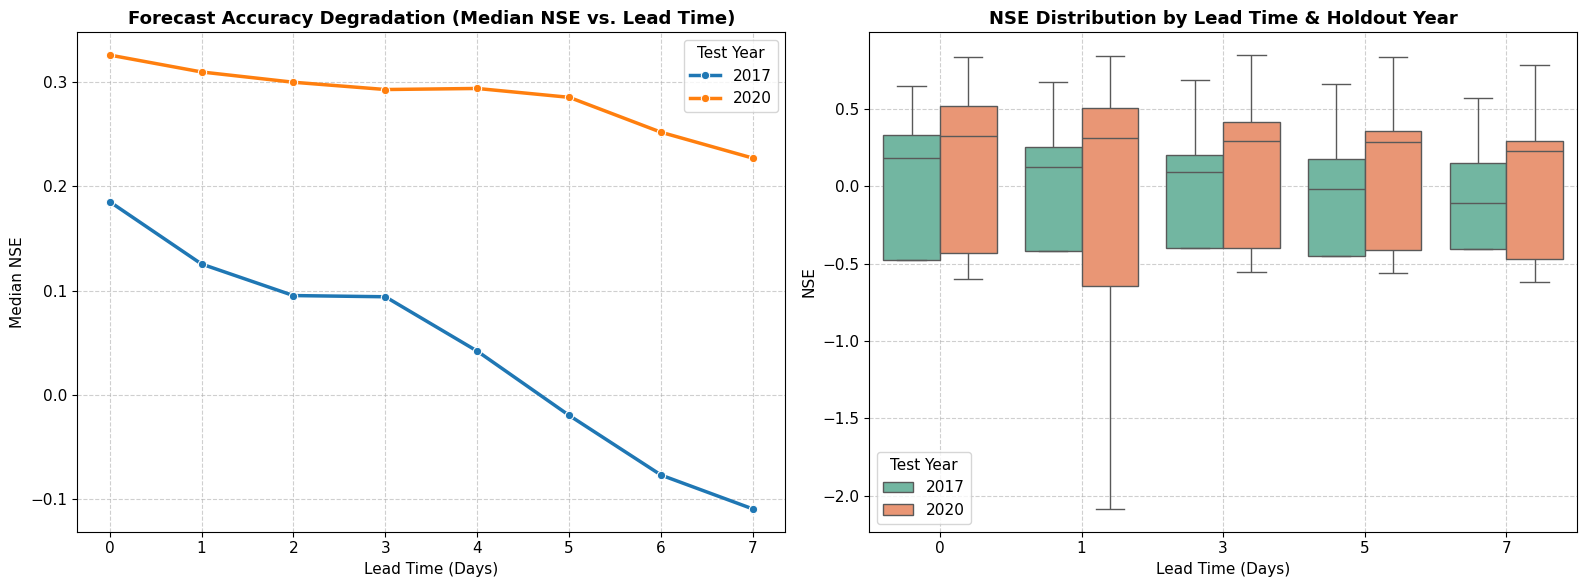

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("white")

# Plot 1: Metric Degradation over Lead Time
ax1 = axes[0]
sns.lineplot(
    data=df_cv_all,
    x="Lead Time (Days)",
    y="NSE",
    hue="Test Year",
    estimator="median",
    errorbar=None,
    marker="o",
    linewidth=2.5,
    palette="tab10",
    ax=ax1
)
ax1.set_title("Forecast Accuracy Degradation (Median NSE vs. Lead Time)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Lead Time (Days)", fontsize=11)
ax1.set_ylabel("Median NSE", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)

# Plot 2: Boxplot of NSE by Lead Time & Test Year
ax2 = axes[1]
sns.boxplot(
    data=df_cv_all[df_cv_all["Lead Time (Days)"].isin([0, 1, 3, 5, 7])],
    x="Lead Time (Days)",
    y="NSE",
    hue="Test Year",
    palette="Set2",
    showfliers=False,
    ax=ax2
)
ax2.set_title("NSE Distribution by Lead Time & Holdout Year", fontsize=13, fontweight="bold")
ax2.set_xlabel("Lead Time (Days)", fontsize=11)
ax2.set_ylabel("NSE", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
display(fig)
plt.close(fig)


## 4. Multi-Lead Streamflow Hydrograph Inspection

Visualizing observed streamflow vs. multi-lead forecasts (e.g. Lead Day 1, Lead Day 3, and Lead Day 7) for holdout catchments across the test periods.


Plotting hydrograph for GRDC_4119200 in fold_test_yr2017_b0_v1...


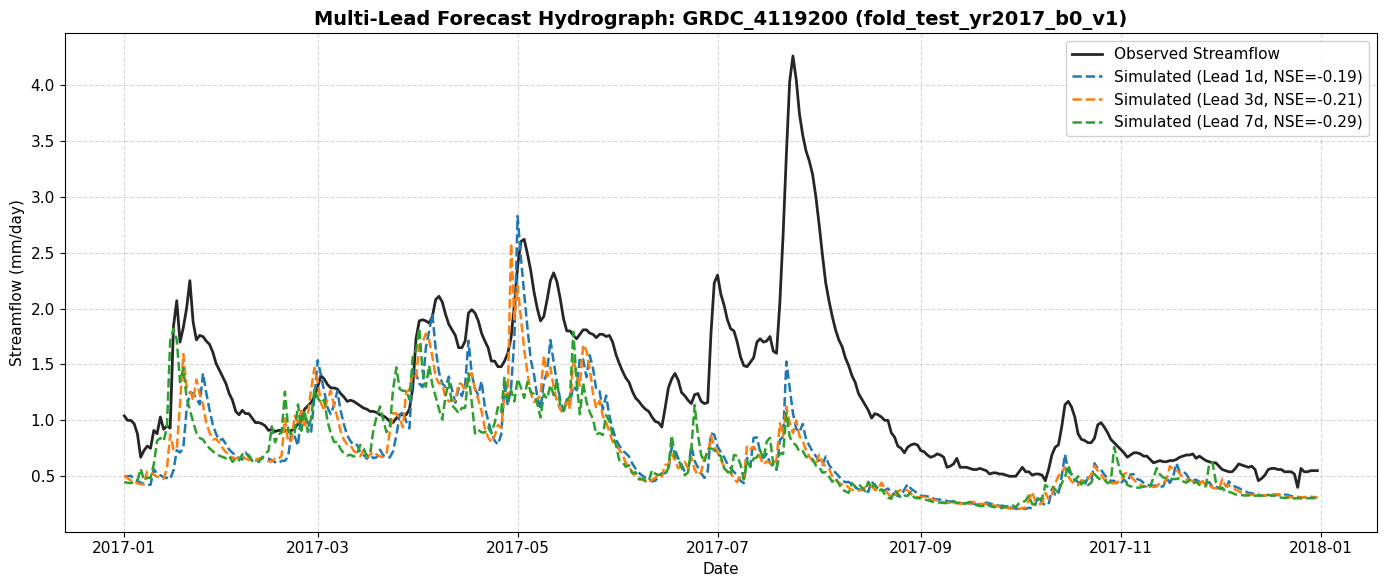

In [5]:
def plot_cv_hydrograph(detailed_results, fold_name, basin_id, lead_times=[1, 3, 7]):
    if fold_name not in detailed_results or basin_id not in detailed_results[fold_name]:
        print(f"Basin {basin_id} not found in {fold_name} results.")
        return
        
    b_data = detailed_results[fold_name][basin_id]
    dates = b_data["dates"]
    
    fig = plt.figure(figsize=(14, 6))
    fig.patch.set_facecolor("white")
    
    # Observed flow
    sample_obs = b_data["lead_times"][lead_times[0]]["obs"]
    plt.plot(dates, sample_obs, label="Observed Streamflow", color="black", linewidth=2.0, alpha=0.85)
    
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    for i, lt in enumerate(lead_times):
        if lt in b_data["lead_times"]:
            sim = b_data["lead_times"][lt]["sim"]
            nse_val = b_data["lead_times"][lt]["metrics"]["NSE"]
            c = colors[i % len(colors)]
            plt.plot(dates, sim, label=f"Simulated (Lead {lt}d, NSE={nse_val:.2f})", color=c, linestyle="--", linewidth=1.8)
            
    plt.title(f"Multi-Lead Forecast Hydrograph: {basin_id} ({fold_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Date", fontsize=11)
    plt.ylabel("Streamflow (mm/day)", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(frameon=True, facecolor="white", framealpha=0.9, loc="upper right")
    plt.tight_layout()
    display(fig)
    plt.close(fig)

# Sample Plot for the first available fold and basin
first_fold = list(detailed_cv_results.keys())[0]
first_basin = list(detailed_cv_results[first_fold].keys())[0]
print(f"Plotting hydrograph for {first_basin} in {first_fold}...")
plot_cv_hydrograph(detailed_cv_results, first_fold, first_basin, lead_times=[1, 3, 7])


## 5. Direct Evaluation of Newly Trained 5,269-Basin Model (XID: 279232102)

Evaluate the newly trained model from `mean_embedding_fast_1fold` (`model_epoch001.pt`) on holdout test basins (Test Year: 2018), and visualize multi-lead hydrographs.

Copying config.yml from CNS...
Copying scaler.nc from CNS...
Copying model_epoch001.pt from CNS...
Copying test_basins.txt from CNS...
Evaluating 5 test basins (Total holdout test basins: 1318)...
Running RegressionTester inference on holdout test set...
Metrics for 1D are calculated over last 1 elements only. Ignoring 7 predictions per sequence.

--- Summary Performance (Median Metrics across evaluated basins) ---


,NSE,KGE,Pearson-r,RMSE
Lead Time (Days),,,,
0,0.081,-0.076,0.498,0.133
1,-0.145,-0.111,0.493,0.163
2,-0.089,-0.093,0.347,0.169
3,0.047,-0.065,0.421,0.146
4,0.142,-0.048,0.492,0.118
5,0.213,-0.034,0.546,0.116
6,0.181,-0.039,0.543,0.108
7,0.139,-0.060,0.547,0.107


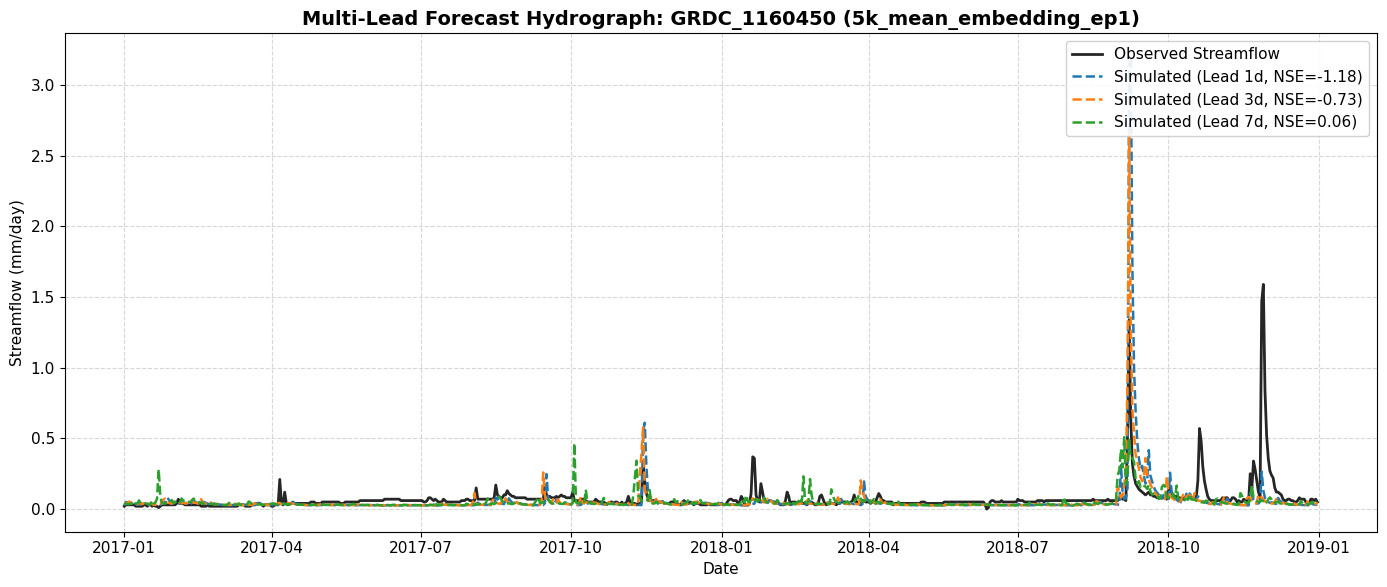

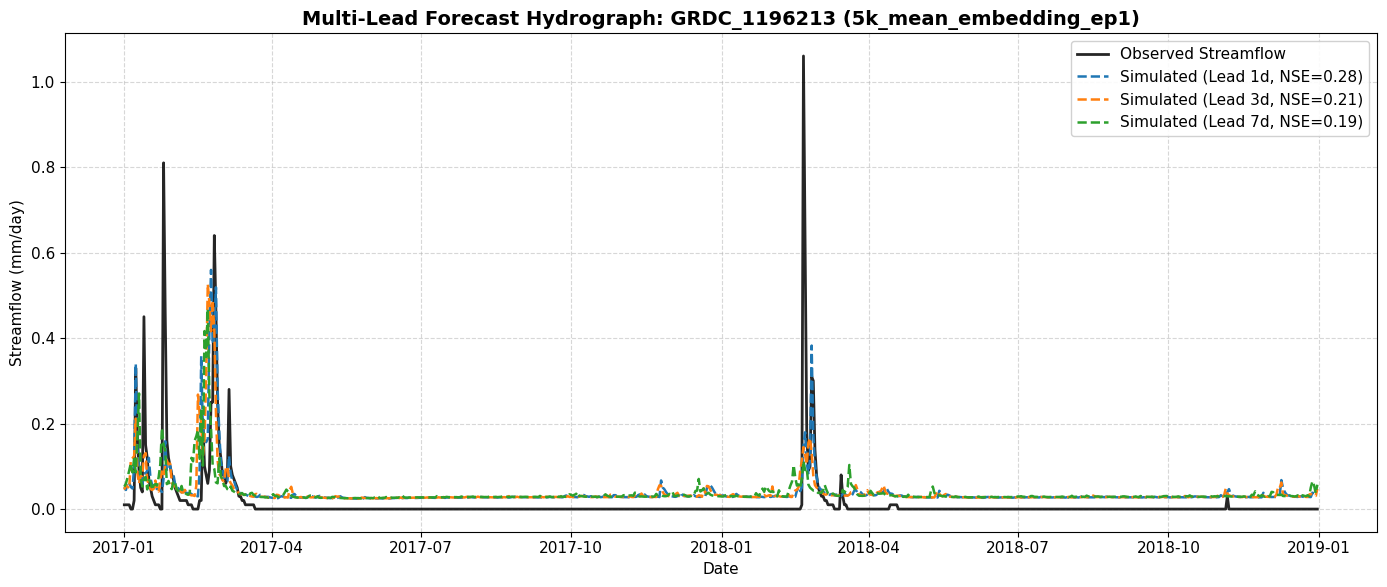

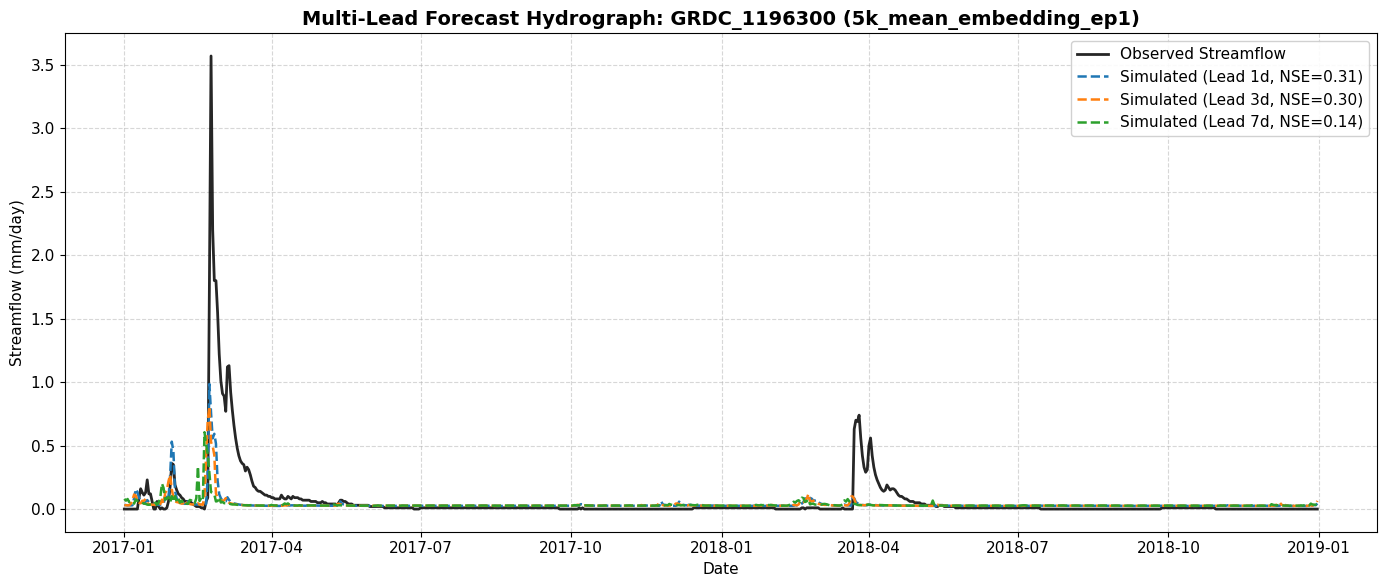

In [6]:
# -----------------------------------------------------------------------------
# Evaluation for Newly Trained 5,269-Basin Mean Embedding Model (XID: 279232102)
# -----------------------------------------------------------------------------
import shutil

# Configuration & Paths
cns_new_run_dir = "/cns/jn-d/home/floods/hydro_model/work/kruparell/mean_embedding_cv_results/mean_embedding_fast_1fold/fold_test_yr2018_b0/me_hs64_ep1/me_cv_test_yr2018_b0_me_hs64_ep1_1208_050138"
local_eval_dir = repo_root / "model-runs" / "mean_embedding_fast_5k_epoch1"
local_eval_dir.mkdir(parents=True, exist_ok=True)

# 1. Download Model Artifacts from CNS
for fname in ["config.yml", "scaler.nc", "model_epoch001.pt"]:
    dst = local_eval_dir / fname
    if not dst.exists() or dst.stat().st_size == 0:
        print(f"Copying {fname} from CNS...")
        cns_cp(f"{cns_new_run_dir}/{fname}", str(dst))

# 2. Get Test Basins
test_basins_cns = "/cns/jn-d/home/floods/hydro_model/work/kruparell/mean_embedding_cv_results/mean_embedding_fast_1fold/fold_test_yr2018_b0/me_hs64_ep1/fold_test_yr2018_b0/test_basins.txt"
local_test_basins_file = local_eval_dir / "test_basins.txt"
if not local_test_basins_file.exists() or local_test_basins_file.stat().st_size == 0:
    print("Copying test_basins.txt from CNS...")
    cns_cp(test_basins_cns, str(local_test_basins_file))

with open(local_test_basins_file, "r") as f:
    all_test_basins = [l.strip() for l in f if l.strip()]

eval_debug_basins = 5  # Set to None for all ~1,318 test basins, or an integer for quick interactive plotting
eval_basins = all_test_basins[:eval_debug_basins] if eval_debug_basins else all_test_basins
print(f"Evaluating {len(eval_basins)} test basins (Total holdout test basins: {len(all_test_basins)})...")

eval_basin_file = local_eval_dir / f"eval_{len(eval_basins)}_basins.txt"
with open(eval_basin_file, "w") as f:
    f.write("\n".join(eval_basins) + "\n")

# 3. Patch Config for Local Inference
with open(local_eval_dir / "config.yml", "r") as f:
    cfg_eval = yaml.safe_load(f)

cfg_eval["run_dir"] = str(local_eval_dir)
cfg_eval["base_run_dir"] = str(local_eval_dir)
cfg_eval["test_basin_file"] = str(eval_basin_file)
cfg_eval["train_basin_file"] = str(eval_basin_file)
cfg_eval["validation_basin_file"] = str(eval_basin_file)
cfg_eval["statics_data_dir"] = "/usr/local/google/home/kruparell/Caravans_V2"
cfg_eval["dynamics_data_dir"] = "/usr/local/google/home/kruparell/Caravans_MultiMet"
cfg_eval["targets_data_dir"] = "/usr/local/google/home/kruparell/Caravans_V2"
cfg_eval["device"] = "cuda:0" if torch.cuda.is_available() else "cpu"
cfg_eval["verbose"] = 0
cfg_eval["epochs"] = 1

with open(local_eval_dir / "config.yml", "w") as f:
    yaml.dump(cfg_eval, f)

cfg_obj = Config(local_eval_dir / "config.yml")

# 4. Run RegressionTester Inference
test_zarr = list((local_eval_dir / "test" / "model_epoch001").glob("test_results.zarr"))
if not test_zarr:
    print("Running RegressionTester inference on holdout test set...")
    tester = RegressionTester(cfg=cfg_obj, run_dir=local_eval_dir, period="test", init_model=True)
    tester.model.eval()
    tester.evaluate(epoch=1, save_results=True)
    test_zarr = list((local_eval_dir / "test" / "model_epoch001").glob("test_results.zarr"))

# 5. Load Results & Metrics
ds_results = xr.open_zarr(test_zarr[0], consolidated=False).compute()
lead_steps = ds_results["time_step"].values
eval_dates = pd.to_datetime(ds_results["date"].values)

new_model_eval_records = []
new_model_preds = {}

for b in eval_basins:
    new_model_preds[b] = {"dates": eval_dates, "lead_times": {}}
    for lt_idx, lt_val in enumerate(lead_steps):
        obs = ds_results["streamflow_obs"].sel(basin=b).isel(freq=0, time_step=lt_idx).values.flatten()
        sim = np.maximum(0.0, ds_results["streamflow_sim"].sel(basin=b).isel(freq=0, time_step=lt_idx).values.flatten())
        
        m = compute_hydro_metrics(obs, sim)
        new_model_eval_records.append({
            "Basin": b,
            "Lead Time (Days)": int(lt_val),
            "NSE": m["NSE"],
            "KGE": m["KGE"],
            "Pearson-r": m["Pearson-r"],
            "RMSE": m["RMSE"],
        })
        new_model_preds[b]["lead_times"][int(lt_val)] = {"obs": obs, "sim": sim, "metrics": m}

df_new_model_metrics = pd.DataFrame(new_model_eval_records)
print("\n--- Summary Performance (Median Metrics across evaluated basins) ---")
display(df_new_model_metrics.groupby("Lead Time (Days)")[["NSE", "KGE", "Pearson-r", "RMSE"]].median().round(3))

# 6. Plot Sample Hydrographs
for sample_basin in eval_basins[:min(3, len(eval_basins))]:
    plot_cv_hydrograph({"5k_mean_embedding_ep1": new_model_preds}, "5k_mean_embedding_ep1", sample_basin, lead_times=[1, 3, 7])